# Лабораторная работа №3 — классическое машинное обучение в NLP

**Корпус:** Twitter US Airline Sentiment, 14 640 твитов; целевая задача — классификация тональности (`negative`, `neutral`, `positive`). Используем исходные тексты, очищенные токены и фиксированное разбиение из лабораторной №1.

Все семь пунктов задания выполнены ниже по порядку. Словари BoW и TF-IDF, IDF и классификаторы обучаются **только на Train**. Поиск и тематическое моделирование используют **весь корпус**, как отдельные задачи без оценки классификатора.

**Запуск:** из корня репозитория выполнить `uv sync`, затем открыть `lab3/lab3.ipynb` с ядром этого окружения. Сначала выполнить `lab1/notebook.ipynb` до «Сохранение данных для лабораторной №2» включительно. Ноутбук №3 запускается сверху вниз из корня репозитория или своей папки. Результаты сохранены в ячейках; подбор LDA требует нескольких минут на CPU.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import json
import math
import platform
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import gensim
from IPython.display import display, Markdown
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, ConfusionMatrixDisplay
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "lab1/notebook.ipynb").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Запустите ноутбук из папки репозитория TextAnalysis.")
DATA_DIR = ROOT / "data/lab1"
if not (DATA_DIR / "documents.jsonl").exists():
    raise FileNotFoundError("Сначала выполните lab1/notebook.ipynb до ячейки сохранения данных.")
manifest = json.loads((DATA_DIR / "manifest.json").read_text(encoding="utf-8"))
assert manifest["schema_version"] == 1
assert hashlib.sha256((DATA_DIR / "documents.jsonl").read_bytes()).hexdigest() == manifest["documents_sha256"]
frame = pd.read_json(DATA_DIR / "documents.jsonl", lines=True).sort_values("row_id").reset_index(drop=True)
assert len(frame) == manifest["rows"] and frame.row_id.is_unique
assert frame.split.value_counts().to_dict() == {"train": manifest["train_rows"], "test": manifest["test_rows"]}
assert set(frame.label) == {"negative", "neutral", "positive"}

# Для классификации сохраняем слова и отрицания; технические маркеры и пунктуацию убираем.
WORD = re.compile(r"[a-z]+(?:['’][a-z]+)?", re.I)
frame["words"] = frame.tokens_clean.map(lambda tokens: [t.lower() for t in tokens if WORD.fullmatch(t)])
frame["text_ml"] = frame.words.map(" ".join)
train = frame[frame.split == "train"].copy()
test = frame[frame.split == "test"].copy()
y_train, y_test = train.label.to_numpy(), test.label.to_numpy()
labels = ["negative", "neutral", "positive"]
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 30)
print(f"Корпус: {len(frame)}; Train: {len(train)}; Test: {len(test)}. SHA-256 экспорта проверен.")
print(f"Python {platform.python_version()}, scikit-learn {sklearn.__version__}, gensim {gensim.__version__}")
display(pd.crosstab(frame.label, frame.split).reindex(labels))

Корпус: 14640; Train: 11712; Test: 2928. SHA-256 экспорта проверен.
Python 3.12.14, scikit-learn 1.8.0, gensim 4.4.0


split,test,train
label,,
negative,1835,7343
neutral,620,2479
positive,473,1890


## 1. Статистическая векторизация: BoW и TF-IDF

BoW хранит число вхождений каждого слова. TF-IDF уменьшает вес слов, встречающихся во многих документах: в scikit-learn используется сглаженный `idf = log((1 + N) / (1 + df)) + 1`, затем векторы нормируются по L2. В обоих случаях используем одинаковые униграммы и `min_df=2`: слова должны встречаться хотя бы в двух документах **Train**. Стоп-слова не удаляем, чтобы сохранить отрицания.

Одинаковые настройки должны дать одинаковую размерность: меняются веса, а не набор признаков. Новые слова Test не добавляются в словарь.

In [2]:
vectorizer_params = dict(tokenizer=str.split, token_pattern=None, lowercase=False, min_df=2)
bow = CountVectorizer(**vectorizer_params)
tfidf = TfidfVectorizer(**vectorizer_params)
X_train_bow = bow.fit_transform(train.text_ml)
X_test_bow = bow.transform(test.text_ml)
X_train_tfidf = tfidf.fit_transform(train.text_ml)
X_test_tfidf = tfidf.transform(test.text_ml)
assert bow.vocabulary_ == tfidf.vocabulary_
assert X_train_bow.shape[1] == X_test_bow.shape[1] == X_train_tfidf.shape[1] == X_test_tfidf.shape[1]
# Независимая проверка: словарь состоит ровно из слов с Train document frequency >= 2.
train_df = Counter(word for words in train.words for word in set(words))
assert set(bow.vocabulary_) == {word for word, count in train_df.items() if count >= 2}
expected_idf = np.array([math.log((1 + len(train)) / (1 + train_df[word])) + 1
                         for word in tfidf.get_feature_names_out()])
assert np.allclose(tfidf.idf_, expected_idf)
display(pd.DataFrame([
    {"Метод": "BoW", "Train": str(X_train_bow.shape), "Test": str(X_test_bow.shape), "Признаков": X_train_bow.shape[1]},
    {"Метод": "TF-IDF", "Train": str(X_train_tfidf.shape), "Test": str(X_test_tfidf.shape), "Признаков": X_train_tfidf.shape[1]},
]))
print("Размерности совпадают; словарь и IDF проверены по Train. Матрицы разреженные.")

Размерности совпадают; словарь и IDF проверены по Train. Матрицы разреженные.


,Метод,Train,Test,Признаков
0,BoW,"(11712, 4938)","(2928, 4938)",4938
1,TF-IDF,"(11712, 4938)","(2928, 4938)",4938


## 2. Обучение двух классификаторов

Выбраны **Multinomial Naive Bayes** и **линейный SVM** (`LinearSVC`). Первый использует статистику признаков при условном предположении их независимости; второй учит линейные границы между классами.

В корпусе преобладают негативные отзывы. Для SVM задаём `class_weight="balanced"`; для Naive Bayes, у которого нет такого параметра, передаём эквивалентные веса документов через `sample_weight`. Вес класса равен `N / (3 × N_класса)` и вычисляется только по Train. После взвешивания суммарный вес каждого класса одинаков. Параметры фиксированы заранее, подбор по Test не проводится.

In [3]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
balance_table = train.groupby("label").size().reindex(labels).to_frame("Документов Train")
balance_table["Доля, %"] = 100 * balance_table["Документов Train"] / len(train)
balance_table["Вес документа"] = [sample_weights[y_train == label][0] for label in labels]
display(balance_table.round(4))
assert np.allclose([sample_weights[y_train == label].sum() for label in labels], len(train) / len(labels))
models = {
    "Naive Bayes": MultinomialNB(alpha=1.0),
    "Linear SVM": LinearSVC(C=1.0, class_weight="balanced", random_state=42, max_iter=5000),
}
models["Naive Bayes"].fit(X_train_tfidf, y_train, sample_weight=sample_weights)
models["Linear SVM"].fit(X_train_tfidf, y_train)
print("Оба классификатора обучены на TF-IDF Train.")

Оба классификатора обучены на TF-IDF Train.


,Документов Train,"Доля, %",Вес документа
label,,,
negative,7343,62.6964,0.5317
neutral,2479,21.1663,1.5748
positive,1890,16.1373,2.0656


## 3. Оценка качества и анализ ошибок

Macro Precision, Macro Recall и Macro F1 вычисляются отдельно для каждого класса, затем усредняются **без весов классов**. Так малочисленные классы влияют на итог столько же, сколько `negative`.

Accuracy сама по себе не отражает качество на всех классах: ответ «negative» на каждый твит уже даёт высокую долю правильных ответов, но полностью пропускает `neutral` и `positive`. Ниже для сравнения приведён такой постоянный прогноз. Accuracy полезна как дополнительная характеристика, но недостаточна для основной оценки этой несбалансированной задачи.

Ошибок Linear SVM: 668 из 2928.


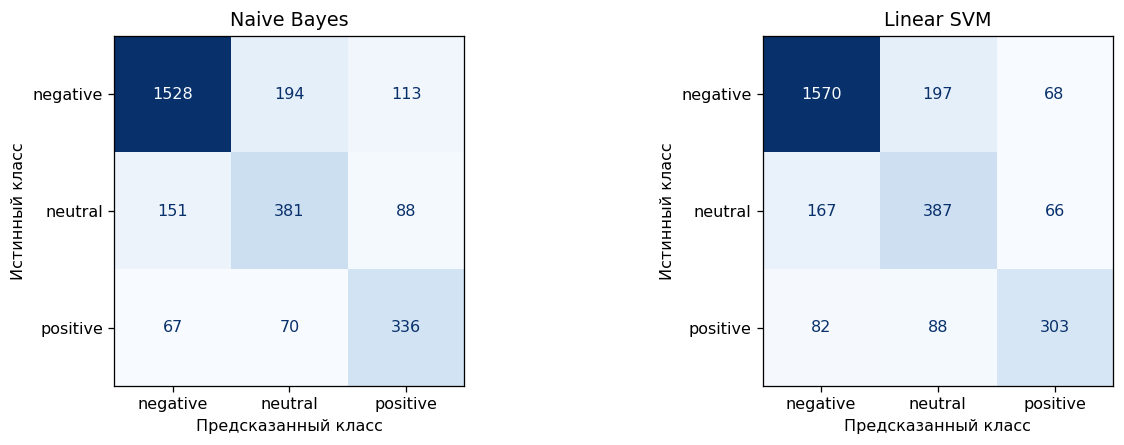

,Macro Precision,Macro Recall,Macro F1,Accuracy
Модель,,,,
Naive Bayes,0.6972,0.7192,0.7070,0.7667
Linear SVM,0.7108,0.7068,0.7081,0.7719
Всегда negative,0.2089,0.3333,0.2568,0.6267


In [4]:
predictions = {name: model.predict(X_test_tfidf) for name, model in models.items()}
metric_rows = []
for name, prediction in {**predictions, "Всегда negative": np.full(len(test), "negative")}.items():
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, prediction, labels=labels, average="macro", zero_division=0)
    metric_rows.append({"Модель": name, "Macro Precision": precision, "Macro Recall": recall,
                        "Macro F1": f1, "Accuracy": accuracy_score(y_test, prediction)})
metrics = pd.DataFrame(metric_rows).set_index("Модель")
display(metrics.round(4))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, prediction) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, prediction, labels=labels,
                                           display_labels=labels, ax=ax, colorbar=False, cmap="Blues")
    ax.set(title=name, xlabel="Предсказанный класс", ylabel="Истинный класс")
fig.tight_layout()
plt.show()
# Анализируем SVM, выбранный заранее, а не по результату Test.
errors = test.loc[y_test != predictions["Linear SVM"], ["row_id", "text", "label"]].copy()
errors["prediction"] = predictions["Linear SVM"][y_test != predictions["Linear SVM"]]
print(f"Ошибок Linear SVM: {len(errors)} из {len(test)}.")

### Пять конкретных ошибок Linear SVM

Анализ ниже относится к фиксированным документам Test. Предсказания взяты из модели, а объяснения — ручная интерпретация текста; это не доказательство внутренней причины решения классификатора.

In [5]:
error_spec = [
    (8, "Положительная реакция NOW I DO! и смайлик :-D противопоставлены отрицанию didn't. Мешок слов не учитывает контекст реплики и разворот оценки; очистка также теряет смайлик."),
    (13, "Похвала: авиакомпания снимает стресс от поездки (take all the stress away). Негативное слово stress имеет другой смысл в этой фразе. Очистка дополнительно удаляет позитивные хештеги #fabulous и #Seductive, заменяя их маркером."),
    (28, "Слово amazing используется саркастически: пассажир возмущён отсутствием холодного воздуха. Модель предсказывает positive, хотя оценка negative. Слова отдельно не передают иронию, а хештеги #noair и #worstflightever удалены при очистке."),
    (30, "В начале — приветствие и cool birthday trip, затем жалоба: не удаётся добавить номер участника из-за имени при бронировании. Смешанный тон, сокращение bked и длинная конструкция могут затруднять выделение основной жалобы; прогноз neutral вместо negative."),
    (117, "Выражение kicked butt здесь означает, что сотрудник отлично справился. Вместе с beautifully и Thank you это похвала, но отдельные слова kicked и butt могут ассоциироваться с негативом. Линейная модель униграмм не представляет значение устойчивого выражения."),
]
rows = []
for row_id, explanation in error_spec:
    selected = errors.loc[errors.row_id == row_id]
    assert len(selected) == 1, "Прогноз изменился: перепроверьте пример ошибки вручную."
    row = selected.iloc[0]
    rows.append({"row_id": row_id, "Текст": row.text, "Истинный класс": row.label,
                 "Прогноз SVM": row.prediction, "Разбор": explanation})
assert len(rows) == 5
display(pd.DataFrame(rows))

,row_id,Текст,Истинный класс,Прогноз SVM,Разбор
0,8,"@virginamerica Well, I didn't…but NOW I DO! :-D",positive,negative,Положительная реакция NOW I DO! и смайлик :-D противопоставлены отрицанию didn't. Мешок слов не учитывает контекст реплики и разворот оценки; очистка также теряет смайлик.
1,13,@VirginAmerica @virginmedia I'm flying your #fabulous #Seductive skies again! U take all the #stress away from travel http://t.co/ahlXHhKiyn,positive,negative,"Похвала: авиакомпания снимает стресс от поездки (take all the stress away). Негативное слово stress имеет другой смысл в этой фразе. Очистка дополнительно удаляет позитивные хештеги #fabulous и #Seductive, заменяя их маркером."
2,28,@VirginAmerica amazing to me that we can't get any cold air from the vents. #VX358 #noair #worstflightever #roasted #SFOtoBOS,negative,positive,"Слово amazing используется саркастически: пассажир возмущён отсутствием холодного воздуха. Модель предсказывает positive, хотя оценка negative. Слова отдельно не передают иронию, а хештеги #noair и #worstflightever удалены при очистке."
3,30,"@VirginAmerica hi! I just bked a cool birthday trip with you, but i can't add my elevate no. cause i entered my middle name during Flight Booking Problems 😢",negative,neutral,"В начале — приветствие и cool birthday trip, затем жалоба: не удаётся добавить номер участника из-за имени при бронировании. Смешанный тон, сокращение bked и длинная конструкция могут затруднять выделение основной жалобы; прогноз neutral вместо negative."
4,117,@VirginAmerica and again! Another rep kicked butt! Naelah represents your team so beautifully!! Thank you!!!,positive,negative,"Выражение kicked butt здесь означает, что сотрудник отлично справился. Вместе с beautifully и Thank you это похвала, но отдельные слова kicked и butt могут ассоциироваться с негативом. Линейная модель униграмм не представляет значение устойчивого выражения."


## 4. Инвертированный индекс по всему корпусу

Каждому уникальному слову сопоставляется отсортированный список исходных `row_id` документов, в которых оно встретилось. Один документ присутствует в списке слова ровно один раз независимо от числа повторений. Используем очищенные слова из первой лабораторной, без искусственных маркеров, с приведением к нижнему регистру. Отдельно сохраняем частоты слов и длины документов — они понадобятся для BM25.

In [6]:
inverted_index = defaultdict(list)
term_frequencies = {}
document_lengths = {}
for row in frame.itertuples():
    counts = Counter(row.words)
    term_frequencies[row.row_id] = counts
    document_lengths[row.row_id] = len(row.words)
    for word in counts:
        inverted_index[word].append(row.row_id)
inverted_index = dict(inverted_index)
by_id = frame.set_index("row_id")
N = len(frame)
avgdl = sum(document_lengths.values()) / N
assert avgdl > 0
assert all(ids == sorted(set(ids)) for ids in inverted_index.values())
assert sum(map(len, inverted_index.values())) == sum(map(len, term_frequencies.values()))
assert all(doc_id in inverted_index[word] for doc_id, counts in term_frequencies.items() for word in counts)
print(f"Документов: {N}; уникальных слов: {len(inverted_index)}; средняя длина: {avgdl:.2f} слов.")
display(pd.DataFrame([{"Слово": word, "Документов": len(inverted_index.get(word, [])),
                       "Первые row_id": inverted_index.get(word, [])[:10]}
                      for word in ["flight", "cancelled", "baggage", "refund"]]))

Документов: 14640; уникальных слов: 10037; средняя длина: 15.80 слов.


,Слово,Документов,Первые row_id
0,flight,3371,"[5, 16, 30, 32, 38, 42, 50, 65, 72, 82]"
1,cancelled,1011,"[83, 92, 129, 133, 145, 154, 158, 161, 182, 195]"
2,baggage,222,"[72, 167, 251, 264, 280, 550, 569, 596, 811, 819]"
3,refund,141,"[213, 506, 554, 678, 697, 703, 786, 793, 845, 865]"


## 5. Поисковый движок Okapi BM25

Запрос обрабатывается той же функцией очистки, что и документы в первой лабораторной. Из индекса берём объединение списков документов для слов запроса (логика **OR**). Для каждого кандидата суммируем вклады совпавших слов:

$$\operatorname{BM25}(d,q)=\sum_{t\in\operatorname{unique}(q)}\operatorname{IDF}(t)\frac{f(t,d)(k_1+1)}{f(t,d)+k_1(1-b+b|d|/\operatorname{avgdl})},$$
$$\operatorname{IDF}(t)=\ln\left(1+\frac{N-\operatorname{df}(t)+0.5}{\operatorname{df}(t)+0.5}\right).$$

Используем положительный вариант IDF, `k1=1.5` и `b=0.75`. Частота слова насыщается, а длина документа учитывается относительно средней длины корпуса. Повтор слова в запросе не меняет результат. При равных оценках сортируем по `row_id`; пустой запрос или отсутствие совпадений дают пустую таблицу.

In [7]:
import html
URL = re.compile(r"(?:https?://|www\.)\S+", re.I)
EMAIL = re.compile(r"\b[\w.+-]+@[\w.-]+\.[a-z]{2,}\b", re.I)
MENTION = re.compile(r"(?<!\w)@[A-Za-z0-9_]+")
HASHTAG = re.compile(r"(?<!\w)#[A-Za-z0-9_]+")
NUMBER = re.compile(r"\b\d+(?:[.,:]\d+)*\b")
EMOJI = re.compile(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]")
TOKEN = re.compile(r"\[[A-Z]+\]|[a-z]+(?:['’][a-z]+)?|[.!?]+|[,;:]", re.I)

def query_words(text):
    text = html.unescape(text)
    for pattern, marker in [(URL, "[URL]"), (EMAIL, "[EMAIL]"), (MENTION, "[USER]"),
                            (HASHTAG, "[TAG]"), (EMOJI, "[EMOJI]"), (NUMBER, "[NUM]")]:
        text = pattern.sub(f" {marker} ", text)
    return [t for t in TOKEN.findall(text.lower()) if WORD.fullmatch(t)]

assert all(query_words(row.text) == row.words for row in frame.itertuples())

def bm25_score(doc_id, terms, k1=1.5, b=0.75):
    counts = term_frequencies[doc_id]
    length_factor = 1 - b + b * document_lengths[doc_id] / avgdl
    score = 0.0
    for word in set(terms):
        frequency = counts.get(word, 0)
        if not frequency:
            continue
        df = len(inverted_index[word])
        idf = math.log1p((N - df + 0.5) / (df + 0.5))
        score += idf * frequency * (k1 + 1) / (frequency + k1 * length_factor)
    return score

def search(query, top_n=5):
    terms = set(query_words(query))
    candidates = {doc_id for word in terms for doc_id in inverted_index.get(word, [])}
    ranked = sorted(((doc_id, bm25_score(doc_id, terms)) for doc_id in candidates),
                    key=lambda pair: (-pair[1], pair[0]))[:top_n]
    return pd.DataFrame([{"row_id": doc_id, "BM25": score, "Текст": by_id.loc[doc_id, "text"]}
                         for doc_id, score in ranked], columns=["row_id", "BM25", "Текст"])

assert search("").empty and search("zzzzunseenwordzzzz").empty
assert search("baggage baggage").equals(search("baggage"))
# Для запроса из одного слова сравниваем результат с прямой формулой, без функции ранжирования.
word = "baggage"
doc_id = inverted_index[word][0]
f = term_frequencies[doc_id][word]
expected = math.log(1 + (N - len(inverted_index[word]) + 0.5) / (len(inverted_index[word]) + 0.5)) * f * 2.5 / (f + 1.5 * (0.25 + 0.75 * document_lengths[doc_id] / avgdl))
assert math.isclose(bm25_score(doc_id, [word]), expected)
for query in ["cancelled flight refund", "lost baggage", "excellent customer service"]:
    display(Markdown(f"**Запрос: {query} — топ-5**"))
    result = search(query)
    assert len(result) == 5 and result.BM25.is_monotonic_decreasing
    display(result.round({"BM25": 4}))

**Запрос: cancelled flight refund — топ-5**

,row_id,BM25,Текст
0,10456,10.8889,@USAirways @AmericanAir won't even refund for a flight they Cancelled Flightled #horriblecustomerservice
1,10573,9.6145,@USAirways trying to Cancelled Flight a flight urgently...get hung up on twice??? Sweet refund policy
2,5192,9.2544,@SouthwestAir reservation (FEHQNE) 21FEB15 | DCA-RSW. Want refund not credit for Cancelled Flightled flight please.
3,14061,9.1958,@AmericanAir my flight I have reserved for tomorrow has been Cancelled Flightled. Can I Cancelled Flight my reservation and get a full refund?
4,786,8.9847,@united agent split up my reservation? Now can't Cancelled Flight and refund credit for 2wks? Why


**Запрос: lost baggage — топ-5**

,row_id,BM25,Текст
0,7988,9.6236,@JetBlue ...second incident of lost baggage. I sent you a DM. Thoughts?
1,1908,9.0279,@United give me a direct number I can call regarding my lost baggage immediately.
2,4416,8.7568,@SouthwestAir do you know that your lost baggage portal http://t.co/hUcLXluV5h doesn't work on mobile? It's a 404 http://t.co/O4ZR27Qpcr
3,5515,8.7568,@SouthwestAir how can customers get in touch with you internationally from Mexico for lost baggage
4,11538,8.7568,@USAirways @BohnJai they lost my bag @PHL baggage handlers broke open my bag and stole my camera


**Запрос: excellent customer service — топ-5**

,row_id,BM25,Текст
0,8772,14.3893,@JetBlue Thank you for your excellent customer service - resolved issue quickly.
1,9666,13.0533,@USAirways #usairways lost a passenger today for not upholding their promise of excellent customer service!!!
2,10700,12.2924,@USAirways you can thank supervisor Jeanine and her coworkers for the excellent customer service they provided
3,9594,11.9443,@USAirways is alright with me. Please give Scott F at BDL a bonus for excellent customer service
4,3167,10.4627,@united 4 reFlight Booking Problemss in last 2 days and each time united wait time was &lt;5 seconds! Kudos to you for excellent customer service!


## 6. LDA: экспериментальный выбор числа тем по C_V

Для LDA нужны **счётчики слов**, а не TF-IDF. Используем весь корпус, удаляем английские стоп-слова, названия аккаунтов авиакомпаний и технический шум. Оставляем буквенные слова длиной от 3 символов, встречающиеся минимум в 10 документах и максимум в 50% корпуса. Эти ограничения уменьшают влияние опечаток, служебных слов и имён перевозчиков на темы.

Для `K ∈ {2, 3, 4, 5, 6, 8, 10}` отдельно обучаем LDA с одинаковыми настройками: 8 проходов по корпусу, до 80 итераций вывода на документ, `random_state=42`. Затем вычисляем настоящую **C_V** через `gensim.CoherenceModel`, используя топ-10 слов тем, совместную встречаемость слов в скользящих окнах и косинусную меру на основе нормированной взаимной информации. `window_size=110`, `processes=1`.

Выбираем максимальное среднее C_V среди проверенных K; при точном равенстве — меньшее K. Это экспериментальный выбор в заданной сетке и при одном фиксированном запуске, а не доказательство единственного числа «истинных» тем. Метки тональности здесь не используются.

Словарь LDA: 1501; документов: 14640; пустых после фильтрации: 233.
K= 2: C_V=0.4157
K= 3: C_V=0.3809
K= 4: C_V=0.4153
K= 5: C_V=0.4471
K= 6: C_V=0.4820
K= 8: C_V=0.4148
K=10: C_V=0.3923
Выбрано K=6: максимум C_V в проверенной сетке.


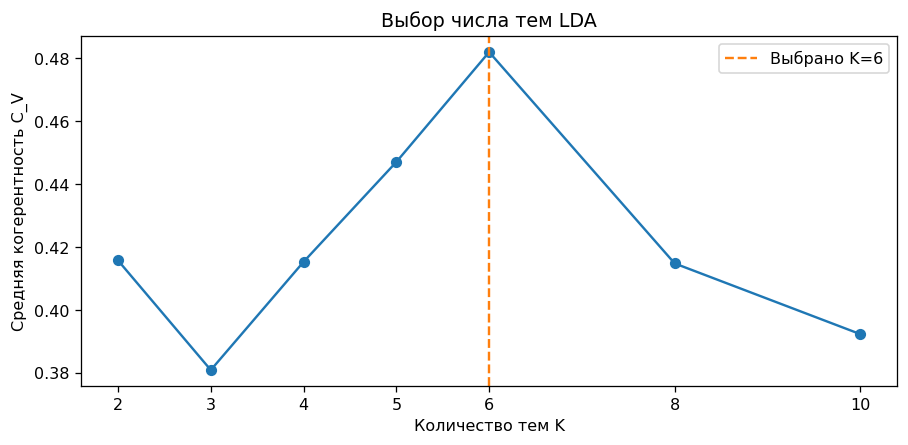

,K,C_V
0,2,0.4157
1,3,0.3809
2,4,0.4153
3,5,0.4471
4,6,0.4820
5,8,0.4148
6,10,0.3923


In [8]:
carrier_words = {"americanair", "usairways", "united", "southwestair", "jetblue", "virginamerica", "rt", "amp"}
topic_stop_words = set(ENGLISH_STOP_WORDS) | carrier_words
topic_texts = [[word for word in words if word.isalpha() and len(word) >= 3 and word not in topic_stop_words]
               for words in frame.words]
dictionary = Dictionary(topic_texts)
dictionary.filter_extremes(no_below=10, no_above=0.5, keep_n=None)
topic_texts = [[word for word in words if word in dictionary.token2id] for words in topic_texts]
lda_corpus = [dictionary.doc2bow(words) for words in topic_texts]
print(f"Словарь LDA: {len(dictionary)}; документов: {len(lda_corpus)}; пустых после фильтрации: {sum(not doc for doc in lda_corpus)}.")
assert len(dictionary) >= 10
K_VALUES = [2, 3, 4, 5, 6, 8, 10]
lda_models = {}
coherence_rows = []
for k in K_VALUES:
    model = LdaModel(corpus=lda_corpus, id2word=dictionary, num_topics=k,
                     random_state=42, passes=8, iterations=80, chunksize=2000,
                     alpha="symmetric", eta="symmetric", eval_every=None)
    cv = CoherenceModel(model=model, texts=topic_texts, dictionary=dictionary,
                        coherence="c_v", topn=10, window_size=110, processes=1).get_coherence()
    lda_models[k] = model
    coherence_rows.append({"K": k, "C_V": float(cv)})
    print(f"K={k:2d}: C_V={cv:.4f}")
coherence_table = pd.DataFrame(coherence_rows)
assert np.isfinite(coherence_table.C_V).all()
best_k = int(coherence_table.sort_values(["C_V", "K"], ascending=[False, True]).iloc[0].K)
best_lda = lda_models[best_k]
display(coherence_table.round(4))
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(coherence_table.K, coherence_table.C_V, marker="o")
ax.axvline(best_k, color="tab:orange", linestyle="--", label=f"Выбрано K={best_k}")
ax.set(xlabel="Количество тем K", ylabel="Средняя когерентность C_V", title="Выбор числа тем LDA", xticks=K_VALUES)
ax.legend()
fig.tight_layout()
plt.show()
print(f"Выбрано K={best_k}: максимум C_V в проверенной сетке.")

## 7. Интерпретация тем

Для каждой темы ниже приведены десять слов с наибольшей вероятностью `P(слово | тема)`, их веса, название и ручное описание. Тема описывает содержание, а не обязательно тональность. На коротких твитах темы могут смешивать несколько сюжетов; названия — интерпретация наиболее весомых слов.

In [9]:
topic_rows = []
for topic_id in range(best_k):
    words_weights = best_lda.show_topic(topic_id, topn=10)
    topic_rows.append({"Тема": topic_id + 1,
                       "Топ-10 слов": ", ".join(word for word, _ in words_weights),
                       "Веса P(слово | тема)": ", ".join(f"{weight:.4f}" for _, weight in words_weights)})
topics_table = pd.DataFrame(topic_rows)
display(topics_table)

,Тема,Топ-10 слов,Веса P(слово | тема)
0,1,"thank, just, email, good, work, great, thanks, guys, bad, flights","0.0386, 0.0196, 0.0193, 0.0187, 0.0155, 0.0140, 0.0137, 0.0122, 0.0115, 0.0105"
1,2,"flight, cancelled, flightled, tomorrow, flights, flighted, help, need, rebooked, dfw","0.1321, 0.0774, 0.0388, 0.0281, 0.0267, 0.0179, 0.0174, 0.0142, 0.0134, 0.0126"
2,3,"seat, yes, seats, just, know, right, want, baggage, reservations, class","0.0232, 0.0204, 0.0190, 0.0148, 0.0136, 0.0125, 0.0121, 0.0116, 0.0112, 0.0107"
3,4,"flight, plane, gate, late, delayed, waiting, hour, time, delay, hours","0.0748, 0.0392, 0.0287, 0.0266, 0.0194, 0.0192, 0.0169, 0.0159, 0.0157, 0.0155"
4,5,"service, customer, thanks, airline, response, worst, lost, experience, guys, rude","0.0771, 0.0594, 0.0421, 0.0239, 0.0178, 0.0171, 0.0144, 0.0134, 0.0132, 0.0125"
5,6,"hold, help, phone, flight, hours, number, wait, change, bag, ticket","0.0378, 0.0350, 0.0333, 0.0298, 0.0229, 0.0176, 0.0171, 0.0159, 0.0157, 0.0149"


### Названия и описания шести тем

| Тема | Название | Интерпретация топ-10 слов |
|---|---|---|
| 1 | Благодарности и оценка работы | `thank`, `good`, `work`, `great`, `thanks` указывают на благодарности и оценку сотрудников. `email` добавляет обращения по почте; `bad` показывает, что тема не исключительно положительная. |
| 2 | Отмена рейсов и перебронирование | `flight`, `cancelled`, `tomorrow`, `help`, `rebooked` описывают отмену рейса и поиск другого вылета. Формы `flightled` и `flighted` — ненормализованные слова корпуса, а не отдельные смысловые категории. |
| 3 | Места и условия поездки | `seat`, `seats`, `reservations`, `class`, `baggage` связаны с местами, бронированием, классом обслуживания и багажом. Частые `yes`, `just`, `know`, `right` делают тему менее однородной: название отражает её наиболее конкретный сюжет. |
| 4 | Задержки и ожидание в аэропорту | `plane`, `gate`, `late`, `delayed`, `waiting`, `hour`, `delay`, `hours` объединяют задержки самолётов и длительное ожидание у выхода на посадку. |
| 5 | Качество обслуживания и жалобы | `service`, `customer`, `response`, `worst`, `experience`, `rude` описывают качество реакции авиакомпании и опыт пассажиров. `thanks` встречается и здесь: тема допускает благодарности наряду с жалобами. |
| 6 | Связь с поддержкой и изменение поездки | `hold`, `help`, `phone`, `hours`, `number`, `wait` связаны с ожиданием ответа по телефону. `change`, `ticket`, `bag` показывают предмет обращения: изменение билета или вопросы багажа. |

Темы 1 и 5 частично пересекаются, а тема 3 содержит много общих слов. Поэтому высокий C_V не гарантирует полностью независимые или одинаково чёткие темы. Короткие тексты и шумные словоформы ограничивают интерпретируемость.

**Результаты:** BoW и TF-IDF дали по 4 938 признаков. Macro F1 на Test составил 0,7070 для Naive Bayes и 0,7081 для Linear SVM — результаты близки. Постоянный прогноз `negative` даёт Accuracy 0,6267, но Macro F1 лишь 0,2568. Реализованы индекс и BM25, показаны три запроса по пять результатов. Среди проверенных K максимум C_V = 0,4820 получен при K = 6; для всех шести тем приведены слова, веса и ручные описания.

Все кодовые ячейки проверены последовательным выполнением в одном процессе Python; таблицы и графики сохранены в ноутбуке. Запуск отдельного ядра Jupyter в среде подготовки ограничен, поэтому его интерфейс здесь не проверялся.

Методические источники: [векторизация scikit-learn](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction), [MultinomialNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html), [LinearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html), [LDA в gensim](https://radimrehurek.com/gensim/models/ldamodel.html), [C_V в gensim](https://radimrehurek.com/gensim/models/coherencemodel.html). [Okapi BM25](https://nlp.stanford.edu/IR-book/html/htmledition/okapi-bm25-a-non-binary-model-1.html).